In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab as py
from sklearn import preprocessing
import scipy.optimize as opt

In [56]:
url =  'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv'
log_data = pd.read_csv(url)
log_data.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [57]:
log_data = log_data[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',   'callcard', 'wireless','churn']]
log_data['churn'] = log_data['churn'].astype('int')
log_data.shape

(200, 10)

In [58]:
x_log = np.asanyarray(log_data[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',   'callcard', 'wireless']])
x_log[0:5]
y_log = np.asanyarray(log_data['churn'])
y_log[0:5]

array([1, 1, 0, 0, 0])

In [59]:
x_log = preprocessing.StandardScaler().fit(x_log).transform(x_log)

In [60]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_log, y_log, test_size = 0.3, random_state = 10)
print ('Train set:', x_train.shape,  y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (140, 9) (140,)
Test set: (60, 9) (60,)


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C=0.01, solver='liblinear').fit(x_train,y_train)
LR
y_pred = LR.predict(x_test)
print(y_pred)

[1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0
 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0]


In [62]:
y_prob = LR.predict_proba(x_test)
print(y_prob)

[[0.40667532 0.59332468]
 [0.71915405 0.28084595]
 [0.65873093 0.34126907]
 [0.51246015 0.48753985]
 [0.53023185 0.46976815]
 [0.57820444 0.42179556]
 [0.54984585 0.45015415]
 [0.44225868 0.55774132]
 [0.70873164 0.29126836]
 [0.54284266 0.45715734]
 [0.69232032 0.30767968]
 [0.68364876 0.31635124]
 [0.5807101  0.4192899 ]
 [0.56553442 0.43446558]
 [0.68858543 0.31141457]
 [0.57938744 0.42061256]
 [0.58369741 0.41630259]
 [0.69505682 0.30494318]
 [0.60272927 0.39727073]
 [0.50235031 0.49764969]
 [0.73450368 0.26549632]
 [0.7830461  0.2169539 ]
 [0.54470813 0.45529187]
 [0.6283903  0.3716097 ]
 [0.52791538 0.47208462]
 [0.43166705 0.56833295]
 [0.45740549 0.54259451]
 [0.5395376  0.4604624 ]
 [0.51851581 0.48148419]
 [0.45604413 0.54395587]
 [0.48635625 0.51364375]
 [0.51144254 0.48855746]
 [0.55852605 0.44147395]
 [0.47933958 0.52066042]
 [0.7032442  0.2967558 ]
 [0.46816887 0.53183113]
 [0.50043901 0.49956099]
 [0.61000221 0.38999779]
 [0.5159358  0.4840642 ]
 [0.47545434 0.52454566]


In [63]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_pred,pos_label=0)

np.float64(0.7142857142857143)

In [64]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print('Confusion Matrix, without Normalization')
    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, y_pred, labels=[1,0]))

[[11  9]
 [ 5 35]]


Confusion Matrix, without Normalization
[[11  9]
 [ 5 35]]


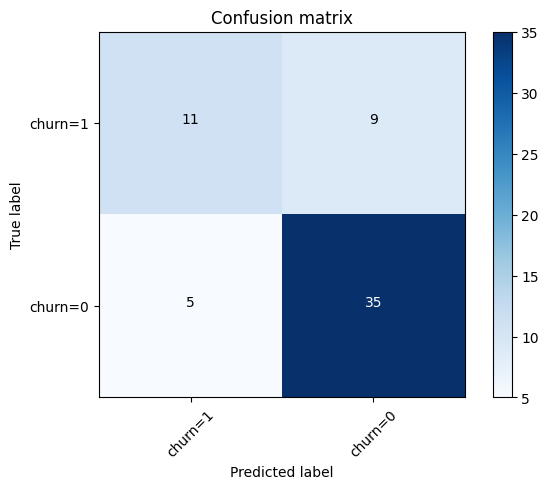

In [65]:
cnf_matrix = confusion_matrix(y_test, y_pred, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')

In [67]:
from sklearn.metrics import f1_score, log_loss
print(classification_report(y_test, y_pred))
print('F1 Score is %.5f' % f1_score(y_test, y_pred))
print('Log loss is %.5f' % log_loss(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.80      0.88      0.83        40
           1       0.69      0.55      0.61        20

    accuracy                           0.77        60
   macro avg       0.74      0.71      0.72        60
weighted avg       0.76      0.77      0.76        60

F1 Score is 0.61111
Log loss is 0.57976


In [73]:
my_log = LogisticRegression(C = 0.001, solver='saga').fit(x_train, y_train)
y_prob = my_log.predict_proba(x_test)
print('Log loss value is %.5f' % log_loss(y_test, y_prob))
print('Confusion Matrix ' , confusion_matrix(y_test, y_pred, labels=[1,0]))
def show_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Greens):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print('Confusion Matrix, without Normalization')
    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="black" if cm[i, j] > thresh else "white")

    plt.tight_layout()
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')

Log loss value is 0.62859
Confusion Matrix  [[35  5]
 [ 9 11]]


Confusion Matrix, without Normalization
[[11  9]
 [ 5 35]]


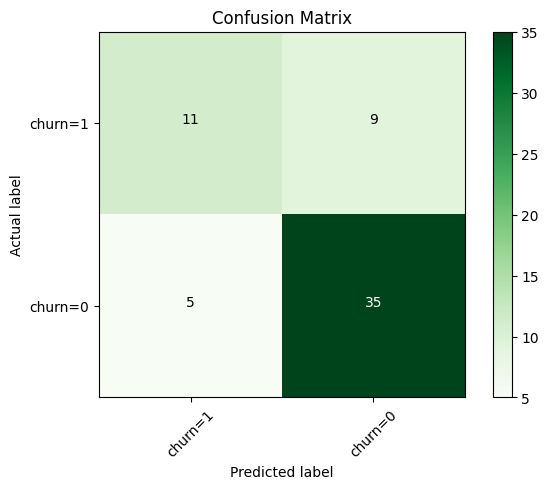

In [78]:
cnf_matrix = confusion_matrix(y_test, y_pred, labels=[1,0])
np.set_printoptions(precision=3)


# Plot non-normalized confusion matrix
plt.figure()
show_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion Matrix')